In [18]:
import pandas as pd
from sklearn.svm import SVC

print("SVM libraries imported successfully")

SVM libraries imported successfully


In [19]:
train = pd.read_csv("../results/outputs/train.csv")
test = pd.read_csv("../results/outputs/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (24000, 16)
Test shape: (6000, 16)


In [20]:
target = "default payment next month"

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (24000, 15)
y_train: (24000,)
X_test: (6000, 15)
y_test: (6000,)


In [21]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully


In [22]:
y_pred = svm_model.predict(X_test)

print("Predictions completed successfully")
print("First 10 predictions:", y_pred[:10])

Predictions completed successfully
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.8185
Precision: 0.6725
Recall   : 0.3497
F1-score : 0.4601


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4447  226]
 [ 863  464]]


In [25]:
print(X_train.describe().loc[["min", "max"]])

     delay_count  max_delay  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  \
min          0.0       -2.0   -2.0   -2.0   -2.0   -2.0   -2.0   -2.0   
max          6.0        8.0    8.0    8.0    8.0    8.0    8.0    8.0   

     LIMIT_BAL  avg_pay_amt  avg_payment_ratio  credit_utilization  PAY_AMT1  \
min  -1.229058    -0.755748          -0.785823           -1.064295 -0.533308   
max   2.611535    10.719427           6.285057           13.247958  6.520354   

     PAY_AMT2  PAY_AMT3  
min -0.492062 -0.476498  
max  6.919833  6.845473  


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaling completed successfully
Scaled train shape: (24000, 15)
Scaled test shape: (6000, 15)


In [27]:
svm_scaled = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = svm_scaled.predict(X_test_scaled)

print("Scaled SVM trained and predictions completed")

Scaled SVM trained and predictions completed


In [28]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled, zero_division=0)
recall_scaled = recall_score(y_test, y_pred_scaled, zero_division=0)
f1_scaled = f1_score(y_test, y_pred_scaled, zero_division=0)

print("Scaled SVM Results")
print("Accuracy :", round(accuracy_scaled, 4))
print("Precision:", round(precision_scaled, 4))
print("Recall   :", round(recall_scaled, 4))
print("F1-score :", round(f1_scaled, 4))

Scaled SVM Results
Accuracy : 0.8173
Precision: 0.6706
Recall   : 0.3421
F1-score : 0.4531


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale"]
}

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", round(grid_search.best_score_, 4))

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-score: 0.4749


In [30]:
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)

print("Tuned SVM Results")
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1-score :", round(f1_tuned, 4))

Tuned SVM Results
Accuracy : 0.8173
Precision: 0.6706
Recall   : 0.3421
F1-score : 0.4531


In [31]:
results = pd.DataFrame(grid_search.cv_results_)

comparison = results[
    ["param_C", "param_kernel", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")

print(comparison.to_string(index=False))

 param_C param_kernel  mean_test_score  rank_test_score
     1.0          rbf         0.474918                1
    10.0          rbf         0.470963                2
     0.1          rbf         0.463027                3
     0.1       linear         0.388076                4
    10.0       linear         0.384164                5
     1.0       linear         0.381424                6


In [32]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print("Tuned SVM Confusion Matrix:")
print(cm_tuned)

Tuned SVM Confusion Matrix:
[[4450  223]
 [ 873  454]]


In [33]:
final_comparison = pd.DataFrame({
    "Model": [
        "SVM - RBF (Unscaled)",
        "SVM - RBF (Scaled)",
        "SVM - Tuned (Best)"
    ],
    "Accuracy": [
        accuracy,
        accuracy_scaled,
        accuracy_tuned
    ],
    "Precision": [
        precision,
        precision_scaled,
        precision_tuned
    ],
    "Recall": [
        recall,
        recall_scaled,
        recall_tuned
    ],
    "F1-score": [
        f1,
        f1_scaled,
        f1_tuned
    ]
})

print(final_comparison.round(4).to_string(index=False))

               Model  Accuracy  Precision  Recall  F1-score
SVM - RBF (Unscaled)    0.8185     0.6725  0.3497    0.4601
  SVM - RBF (Scaled)    0.8173     0.6706  0.3421    0.4531
  SVM - Tuned (Best)    0.8173     0.6706  0.3421    0.4531


In [34]:
from sklearn.metrics import classification_report

print("Classification Report - SVM")
print(classification_report(y_test, y_pred_tuned, target_names=["Non-Default", "Default"]))

Classification Report - SVM
              precision    recall  f1-score   support

 Non-Default       0.84      0.95      0.89      4673
     Default       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



# Support Vector Machine (SVM)

## 1. Introduction

Support Vector Machine (SVM) is a supervised machine learning algorithm
used for classification problems.

In this project, SVM is used to predict whether a customer will default
on their credit card payment.

The target variable is:

- 0 → Non-Default
- 1 → Default

The SVM model was evaluated using Accuracy, Precision, Recall, and F1-score.
Different kernels and hyperparameter values were also tested using
GridSearchCV.

## 2. Why SVM is Suitable for This Problem

The assigned problem is a binary classification problem because the target
variable contains two classes:

- 0 → Non-Default
- 1 → Default

SVM is suitable because it is designed for classification tasks and can
separate observations belonging to different classes using a decision boundary.

SVM also provides different kernel functions such as Linear and RBF kernels,
which allow the model to handle different types of relationships between
the input features and the target.

In this project, the RBF kernel was also tested because it can model
non-linear relationships between the features.

## 3. Dataset and Preprocessing

The dataset was divided into training and testing sets.

- Training data: 24,000 records
- Testing data: 6,000 records
- Input features: 15
- Target variable: `default payment next month`

The target variable was separated from the input features before training the SVM model.

Since SVM performance can be affected by differences in feature scales, StandardScaler was also applied to create a scaled version of the training and testing features.

The scaler was fitted only on the training data and then applied to the test data to avoid data leakage.

## 4. SVM Model Implementation

The Support Vector Machine model was implemented using the `SVC` class
from the Scikit-learn library.

The initial SVM model used the following hyperparameters:

- Kernel: RBF
- C: 1
- Gamma: `scale`

The model was trained using the training dataset and then used to predict
the target classes in the test dataset.

The initial model was evaluated using Accuracy, Precision, Recall, and
F1-score.

## 5. Baseline SVM Results

The initial SVM model was trained using the RBF kernel with C = 1 and
gamma = `scale`.

The baseline model achieved the following results on the test dataset:

- Accuracy: 81.85%
- Precision: 67.25%
- Recall: 34.97%
- F1-score: 46.01%

The model achieved a relatively high accuracy, but the recall for the
Default class was comparatively low. This indicates that the model
missed a number of customers who actually defaulted.

## 6. Feature Scaling

Feature scaling was performed using `StandardScaler` from Scikit-learn.

The training data was used to fit the scaler, and the same transformation
was applied to the test data.

A scaled SVM model was then trained using the RBF kernel with:

- C = 1
- Gamma = `scale`

The scaled model was evaluated using the same evaluation metrics so that
its performance could be compared with the unscaled baseline model.

## 7. Hyperparameter Tuning

Hyperparameter tuning was performed using `GridSearchCV`.

The following hyperparameters were tested:

- C: 0.1, 1, 10
- Kernel: Linear, RBF
- Gamma: `scale`

A 3-fold cross-validation strategy was used.

The F1-score was selected as the scoring metric because the dataset contains
two classes and the model's ability to identify the Default class is important.

The best combination obtained from GridSearchCV was:

- C = 1
- Kernel = RBF
- Gamma = `scale`

The best cross-validation F1-score was 0.4749.

## 8. SVM Model Comparison

Different SVM configurations were evaluated to compare their performance.

| SVM Variant | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| RBF - Unscaled | 81.85% | 67.25% | 34.97% | 46.01% |
| RBF - Scaled | 81.73% | 67.06% | 34.21% | 45.31% |
| Tuned - Best | 81.73% | 67.06% | 34.21% | 45.31% |

The unscaled RBF SVM achieved the highest test accuracy and F1-score
among the tested configurations.

GridSearchCV selected C = 1, RBF kernel, and gamma = `scale` as the
best configuration based on cross-validation F1-score.

## 9. Confusion Matrix and Classification Report

The tuned SVM model produced the following confusion matrix:

[[4450, 223],
 [873, 454]]

The results can be interpreted as:

- True Negative (TN) = 4450
- False Positive (FP) = 223
- False Negative (FN) = 873
- True Positive (TP) = 454

The classification report showed that the Non-Default class achieved a
recall of 95%, while the Default class achieved a recall of 34%.

This indicates that the model performs well in identifying Non-Default
customers, but it has difficulty identifying all actual Default customers.

## 10. Limitations and Possible Improvements

### Limitations

The main limitation of the SVM model is its relatively low recall for the
Default class.

Although the overall accuracy was 81.73% for the tuned model, the recall
for the Default class was only 34%. This means that the model failed to
identify a significant number of customers who actually defaulted.

Another limitation is that the model performance did not improve after
feature scaling and hyperparameter tuning compared with the unscaled
baseline SVM.

### Possible Improvements

Future improvements could include:

- Handling the class imbalance more effectively.
- Testing different class weights.
- Exploring a wider range of SVM hyperparameters.
- Testing additional preprocessing techniques.
- Comparing SVM with other classification models.

## 11. Conclusion

In this project, Support Vector Machine (SVM) was implemented as a binary
classification model to predict credit card payment default.

Different SVM configurations were tested using RBF and Linear kernels,
different C values, feature scaling, and GridSearchCV hyperparameter tuning.

The unscaled RBF SVM achieved the best test performance among the tested
configurations, with:

- Accuracy: 81.85%
- Precision: 67.25%
- Recall: 34.97%
- F1-score: 46.01%

GridSearchCV identified C = 1, RBF kernel, and gamma = `scale` as the best
configuration based on cross-validation F1-score.

Overall, SVM provided reasonable classification performance, but improving
the recall of the Default class remains an important area for future
improvement.

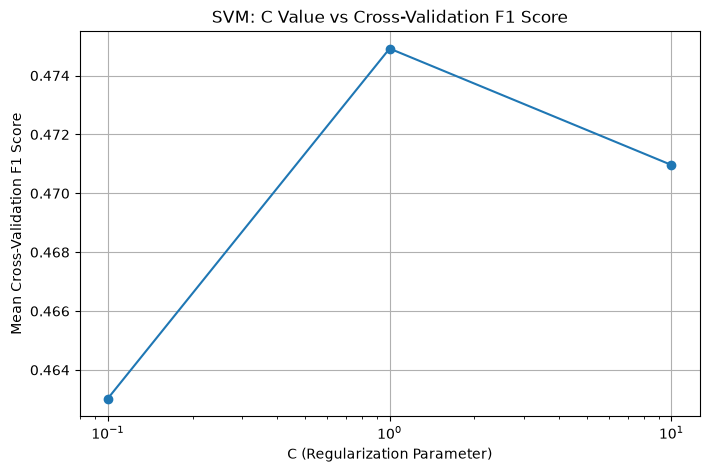

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid_search.cv_results_)

rbf_results = results[results["param_kernel"] == "rbf"].copy()
rbf_results["C"] = rbf_results["param_C"].astype(float)
rbf_results = rbf_results.sort_values("C")

plt.figure(figsize=(8, 5))

plt.plot(
    rbf_results["C"],
    rbf_results["mean_test_score"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("C (Regularization Parameter)")
plt.ylabel("Mean Cross-Validation F1 Score")
plt.title("SVM: C Value vs Cross-Validation F1 Score")
plt.grid(True)
plt.show()

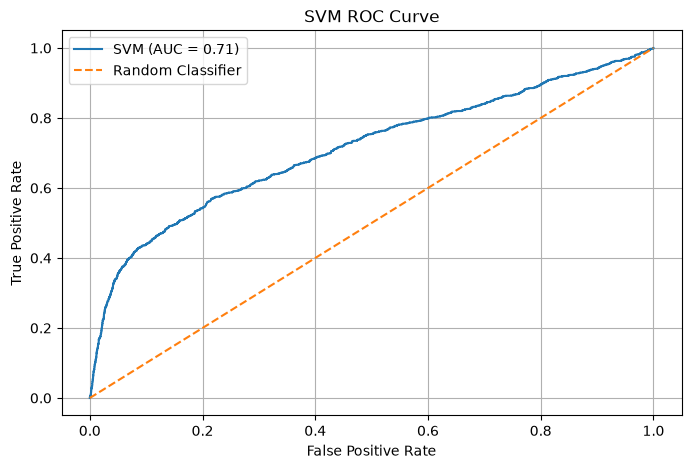

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Use the best SVM model from GridSearchCV
best_svm = grid_search.best_estimator_

# Decision scores
y_scores = best_svm.decision_function(X_test_scaled)

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# Plot ROC Curve
plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

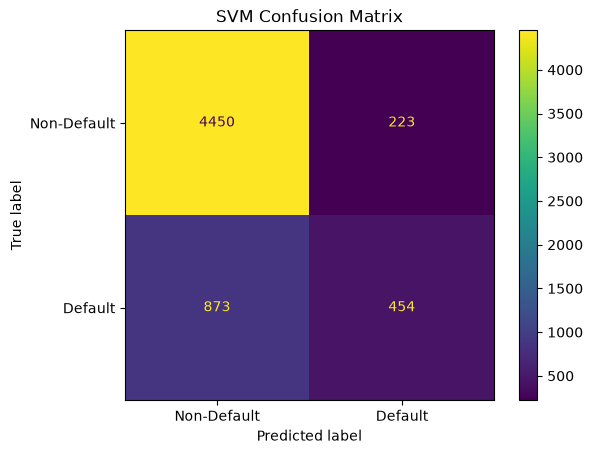

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned,
    display_labels=["Non-Default", "Default"]
)

plt.title("SVM Confusion Matrix")
plt.show()

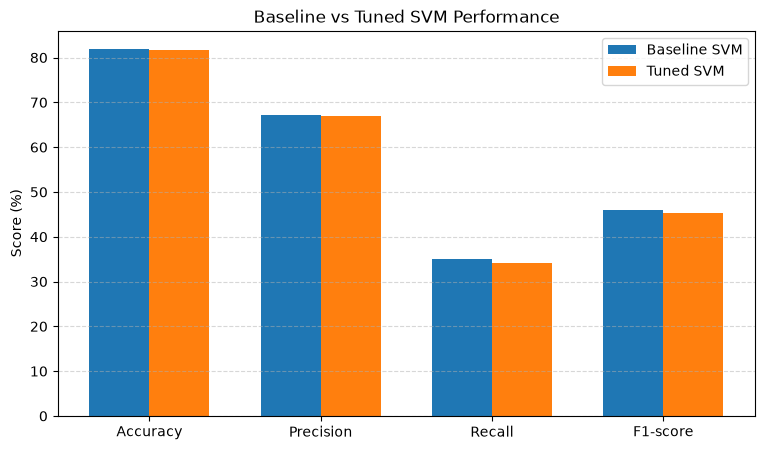

In [23]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

baseline_scores = [81.85, 67.25, 34.97, 46.01]
tuned_scores = [81.73, 67.06, 34.21, 45.31]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, baseline_scores, width, label="Baseline SVM")
plt.bar(x + width/2, tuned_scores, width, label="Tuned SVM")

plt.xticks(x, metrics)
plt.ylabel("Score (%)")
plt.title("Baseline vs Tuned SVM Performance")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

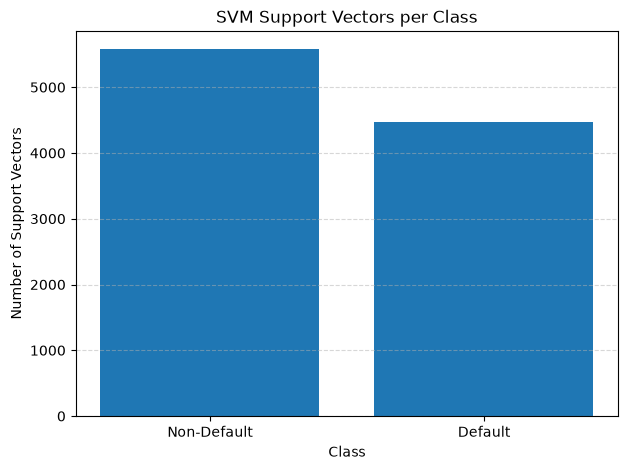

Support vectors per class:
Non-Default: 5575
Default: 4469


In [24]:
import matplotlib.pyplot as plt

support_vectors = best_svm.n_support_

classes = ["Non-Default", "Default"]

plt.figure(figsize=(7, 5))

plt.bar(classes, support_vectors)

plt.xlabel("Class")
plt.ylabel("Number of Support Vectors")
plt.title("SVM Support Vectors per Class")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

print("Support vectors per class:")
print("Non-Default:", support_vectors[0])
print("Default:", support_vectors[1])